# Event Study — Efecto Causal de Festivos sobre la Demanda de TransMilenio 2025

**Pregunta:** ¿Cuál es el efecto causal de un festivo sobre la demanda del sistema?  
**Método:** Event Study con ventana [−5, +5] días alrededor de cada festivo.  
**Identificación:** Los festivos son determinados por ley (exógenos a la demanda).  
**Especificación:**
$$
\log(\text{total}_t) = \sum_{k=-5}^{+5} \beta_k \cdot \mathbf{1}[t = \text{festivo} + k] + \delta_{\text{dow}} + \delta_{\text{month}} + \varepsilon_t
$$
Baseline omitido: $k = -1$ (día anterior al festivo).

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import warnings
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path

warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Cargar y agregar datos a nivel diario del sistema

In [2]:
files = sorted(glob.glob(str(PROJ / 'data/processed/parquet/*.parquet')))
print(f"Cargando {len(files)} archivos...")

rows = []
for f in files:
    d = pd.read_parquet(f)
    rows.append({
        'fecha': d.fecha.iloc[0],
        'total': int(d.total.sum()),
    })

daily = (
    pd.DataFrame(rows)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
      .sort_values('fecha')
      .reset_index(drop=True)
)
daily['log_total'] = np.log(daily.total)
daily['dow']       = daily.fecha.dt.dayofweek   # 0=lunes, 6=domingo
daily['month']     = daily.fecha.dt.month

print(f"Panel: {len(daily)} días  |  {daily.fecha.min().date()} → {daily.fecha.max().date()}")
print(f"Validaciones totales 2025: {daily.total.sum():,.0f}")
daily.head()

Cargando 364 archivos...


Panel: 364 días  |  2025-01-01 → 2025-12-31
Validaciones totales 2025: 1,234,247,409


,fecha,total,log_total,dow,month
0,2025-01-01,720425,13.487597,2,1
1,2025-01-02,2150252,14.581096,3,1
2,2025-01-03,2350676,14.670214,4,1
3,2025-01-04,1851148,14.431317,5,1
4,2025-01-05,1148889,13.954306,6,1


## 2. Calendario de festivos Colombia 2025

In [3]:
with open(PROJ / 'data/external/festivos_co_2025.json') as fh:
    festivos_raw = json.load(fh)

festivos_df = (
    pd.DataFrame(festivos_raw)[['date', 'localName', 'name']]
      .assign(date=lambda x: pd.to_datetime(x.date))
)
festivos_set = set(festivos_df.date)

print(f"{len(festivos_df)} festivos cargados:\n")
for _, r in festivos_df.iterrows():
    day = r.date
    h_row = daily[daily.fecha == day]
    total_str = f"{h_row.total.values[0]:>12,.0f}" if len(h_row) else "         N/A"
    print(f"  {day.date()}  {day.day_name()[:3]}  {total_str} val.   {r.localName}")

18 festivos cargados:

  2025-01-01  Wed       720,425 val.   Año Nuevo
  2025-01-06  Mon     1,118,238 val.   Día de los Reyes Magos
  2025-03-24  Mon     1,279,086 val.   Día de San José
  2025-04-17  Thu     1,221,300 val.   Jueves Santo
  2025-04-18  Fri       999,148 val.   Viernes Santo
  2025-05-01  Thu     1,467,427 val.   Primero de Mayo
  2025-06-02  Mon     1,301,533 val.   Ascensión del señor
  2025-06-23  Mon     1,255,629 val.   Corpus Christi
  2025-06-30  Mon     1,313,649 val.   San Pedro y San Pablo
  2025-06-30  Mon     1,313,649 val.   Sagrado Corazón
  2025-07-20  Sun     1,548,850 val.   Declaracion de la Independencia de Colombia
  2025-08-07  Thu     1,415,734 val.   Batalla de Boyacá
  2025-08-18  Mon     1,276,672 val.   La Asunción
  2025-10-13  Mon     1,250,880 val.   Día de la Raza
  2025-11-03  Mon     1,428,684 val.   Dia de los Santos
  2025-11-17  Mon     1,357,482 val.   Independencia de Cartagena
  2025-12-08  Mon     1,337,201 val.   La Inmaculada C

## 3. Construcción de dummies del event study

Para cada $k \in [-5, +5]$, la variable `es_k` toma valor 1 si la fecha $t$ está exactamente $k$ días después de algún festivo:
$$
\text{es\_k}_t = \mathbf{1}[(t - k) \in \mathcal{H}]
$$
donde $\mathcal{H}$ es el conjunto de fechas festivas.

In [4]:
WINDOW = 5

def col_name(k):
    return f'es_{"m" if k < 0 else "p"}{abs(k)}'

for k in range(-WINDOW, WINDOW + 1):
    daily[col_name(k)] = daily.fecha.apply(
        lambda d, k=k: int((d - pd.Timedelta(days=k)) in festivos_set)
    )

all_es_cols = [col_name(k) for k in range(-WINDOW, WINDOW + 1)]
daily['n_overlap'] = daily[all_es_cols].sum(axis=1)

print(f"Días dentro de al menos una ventana de festivo : {(daily.n_overlap > 0).sum()}")
print(f"Días con solapamiento de dos o más festivos    : {(daily.n_overlap > 1).sum()}")
print(f"Días 'limpios' fuera de toda ventana          : {(daily.n_overlap == 0).sum()}")

Días dentro de al menos una ventana de festivo : 161
Días con solapamiento de dos o más festivos    : 20
Días 'limpios' fuera de toda ventana          : 203


## 4. Regresión OLS — Event Study

Baseline omitido: $k = -1$ (`es_m1`). Los errores estándar son HC3 (robustos a heterocedasticidad).

In [5]:
# Omitir k=-1 como baseline
event_cols = [col_name(k) for k in range(-WINDOW, WINDOW + 1) if k != -1]
formula = 'log_total ~ ' + ' + '.join(event_cols) + ' + C(dow) + C(month)'

ols = smf.ols(formula, data=daily).fit(cov_type='HC3')

print(f"N = {int(ols.nobs)} días")
print(f"R²= {ols.rsquared:.3f}   R²_adj = {ols.rsquared_adj:.3f}")
print(f"F-stat = {ols.fvalue:.1f}   p-value = {ols.f_pvalue:.2e}")

N = 364 días
R²= 0.928   R²_adj = 0.922
F-stat = 199.5   p-value = 4.06e-189


## 5. Coeficientes del event study

In [6]:
coef_rows = []
for k in range(-WINDOW, WINDOW + 1):
    if k == -1:
        coef_rows.append({'k': k, 'b': 0., 'lo': 0., 'hi': 0., 'pval': np.nan})
        continue
    col = col_name(k)
    ci  = ols.conf_int().loc[col]
    coef_rows.append({
        'k': k,
        'b': ols.params[col],
        'lo': ci[0],
        'hi': ci[1],
        'pval': ols.pvalues[col],
    })

res = pd.DataFrame(coef_rows).set_index('k')
res['pct'] = (np.exp(res.b) - 1) * 100
res['sig'] = res.pval.apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')))

print("k       β       IC 95%              % cambio   p-val   sig")
print("-" * 65)
for k, row in res.iterrows():
    print(f"{k:+3d}   {row.b:+7.4f}   [{row.lo:+7.4f}, {row.hi:+7.4f}]   "
          f"{row.pct:+7.1f}%   {'' if np.isnan(row.pval) else f'{row.pval:.3f}':>6}   {row.sig}")

k       β       IC 95%              % cambio   p-val   sig
-----------------------------------------------------------------
 -5   -0.0582   [-0.1561, +0.0397]      -5.7%    0.244   
 -4   -0.0511   [-0.1374, +0.0353]      -5.0%    0.247   
 -3   -0.0570   [-0.1149, +0.0009]      -5.5%    0.054   *
 -2   -0.0815   [-0.1356, -0.0275]      -7.8%    0.003   ***
 -1   +0.0000   [+0.0000, +0.0000]      +0.0%            
 +0   -1.1280   [-1.3263, -0.9297]     -67.6%    0.000   ***
 +1   -0.1287   [-0.2240, -0.0334]     -12.1%    0.008   ***
 +2   -0.0833   [-0.1681, +0.0015]      -8.0%    0.054   *
 +3   -0.0391   [-0.0871, +0.0089]      -3.8%    0.110   
 +4   -0.0397   [-0.0881, +0.0086]      -3.9%    0.107   
 +5   -0.0285   [-0.0862, +0.0291]      -2.8%    0.332   


## 6. Gráfico del event study

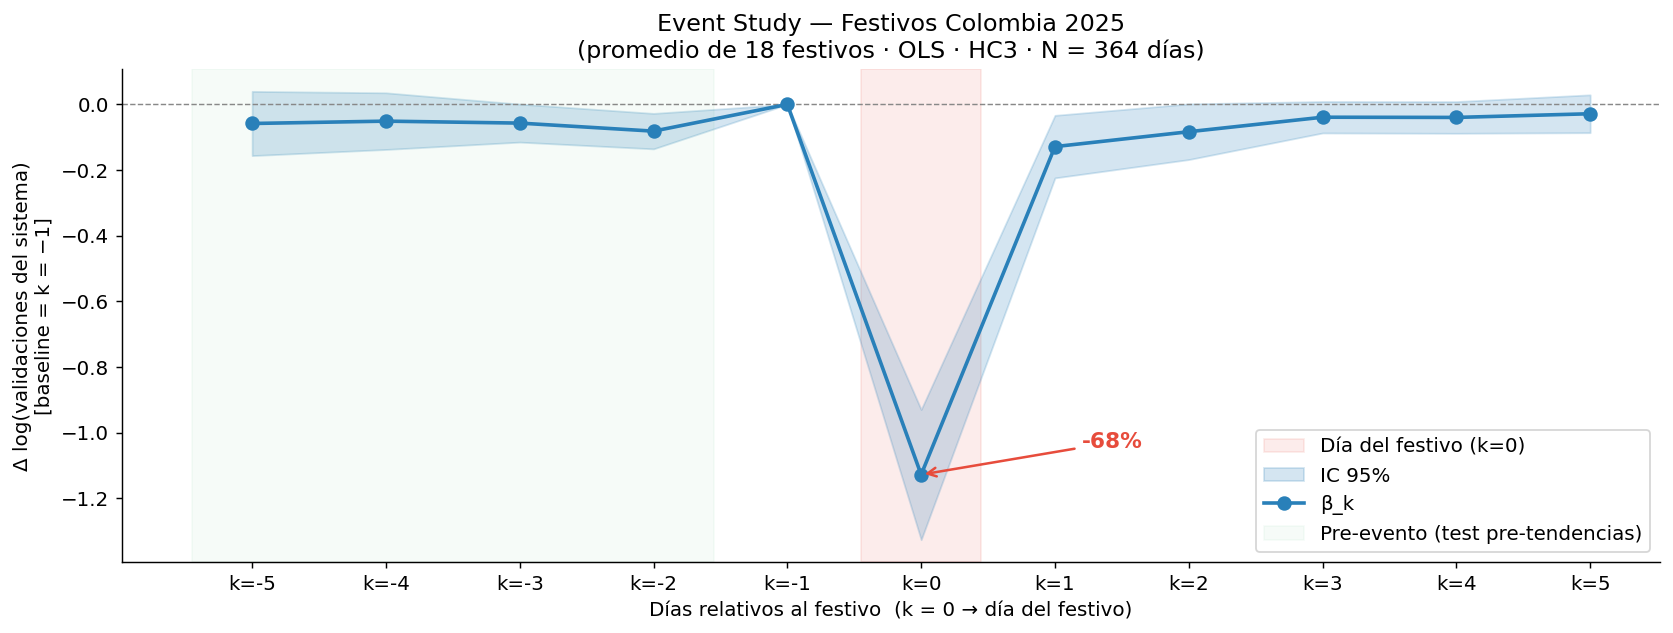

Figura guardada en reports/figures/event_study_festivos.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.axhline(0, color='#888', lw=0.8, ls='--')
ax.axvspan(-0.45, 0.45, alpha=0.10, color='#e74c3c', zorder=0, label='Día del festivo (k=0)')
ax.fill_between(res.index, res.lo, res.hi, alpha=0.20, color='#2980b9', label='IC 95%')
ax.plot(res.index, res.b, 'o-', color='#2980b9', ms=7, lw=2, label='β_k')

# Anotar efecto en k=0
b0, pct0 = res.loc[0, 'b'], res.loc[0, 'pct']
ax.annotate(
    f"{pct0:+.0f}%",
    xy=(0, b0), xytext=(1.2, b0 + 0.08),
    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.4),
    color='#e74c3c', fontweight='bold', fontsize=12,
)

# Destacar zona pre-evento (test de pre-tendencias)
ax.axvspan(-WINDOW - 0.45, -1.55, alpha=0.04, color='#27ae60', label='Pre-evento (test pre-tendencias)')

ax.set_xticks(range(-WINDOW, WINDOW + 1))
ax.set_xticklabels([f'k={k}' for k in range(-WINDOW, WINDOW + 1)])
ax.set_xlabel("Días relativos al festivo  (k = 0 → día del festivo)")
ax.set_ylabel("Δ log(validaciones del sistema)\n[baseline = k = −1]")
ax.set_title(
    f"Event Study — Festivos Colombia 2025\n"
    f"(promedio de {len(festivos_df)} festivos · OLS · HC3 · N = {int(ols.nobs)} días)"
)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/event_study_festivos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en reports/figures/event_study_festivos.png")

## 7. Efectos individuales por festivo

Comparamos cada festivo contra la mediana del mismo día de semana en la semana típica (sin festivos).

In [8]:
# Mediana por día de semana, excluyendo festivos y sus ventanas
daily_clean = daily[daily.n_overlap == 0].copy()
dow_median  = daily_clean.groupby('dow')['total'].median()

ind_rows = []
for _, frow in festivos_df.iterrows():
    h = frow.date
    h_data = daily[daily.fecha == h]
    if len(h_data) == 0:
        continue
    total_h = h_data.total.values[0]
    baseline = dow_median[h.dayofweek]
    pct = (total_h / baseline - 1) * 100
    ind_rows.append({
        'Fecha'      : str(h.date()),
        'Día'        : h.day_name()[:3],
        'Festivo'    : frow.localName,
        'Validaciones': total_h,
        'Efecto (%)'  : round(pct, 1),
    })

ind_eff = pd.DataFrame(ind_rows).sort_values('Efecto (%)')
print(ind_eff.to_string(index=False))

     Fecha Día                                     Festivo  Validaciones  Efecto (%)
2025-01-01 Wed                                   Año Nuevo        720425       -82.9
2025-12-25 Thu                                     Navidad        849519       -79.6
2025-04-18 Fri                               Viernes Santo        999148       -76.1
2025-01-06 Mon                      Día de los Reyes Magos       1118238       -72.6
2025-04-17 Thu                                Jueves Santo       1221300       -70.7
2025-10-13 Mon                              Día de la Raza       1250880       -69.4
2025-06-23 Mon                              Corpus Christi       1255629       -69.2
2025-08-18 Mon                                 La Asunción       1276672       -68.7
2025-03-24 Mon                             Día de San José       1279086       -68.7
2025-06-02 Mon                         Ascensión del señor       1301533       -68.1
2025-06-30 Mon                             Sagrado Corazón       

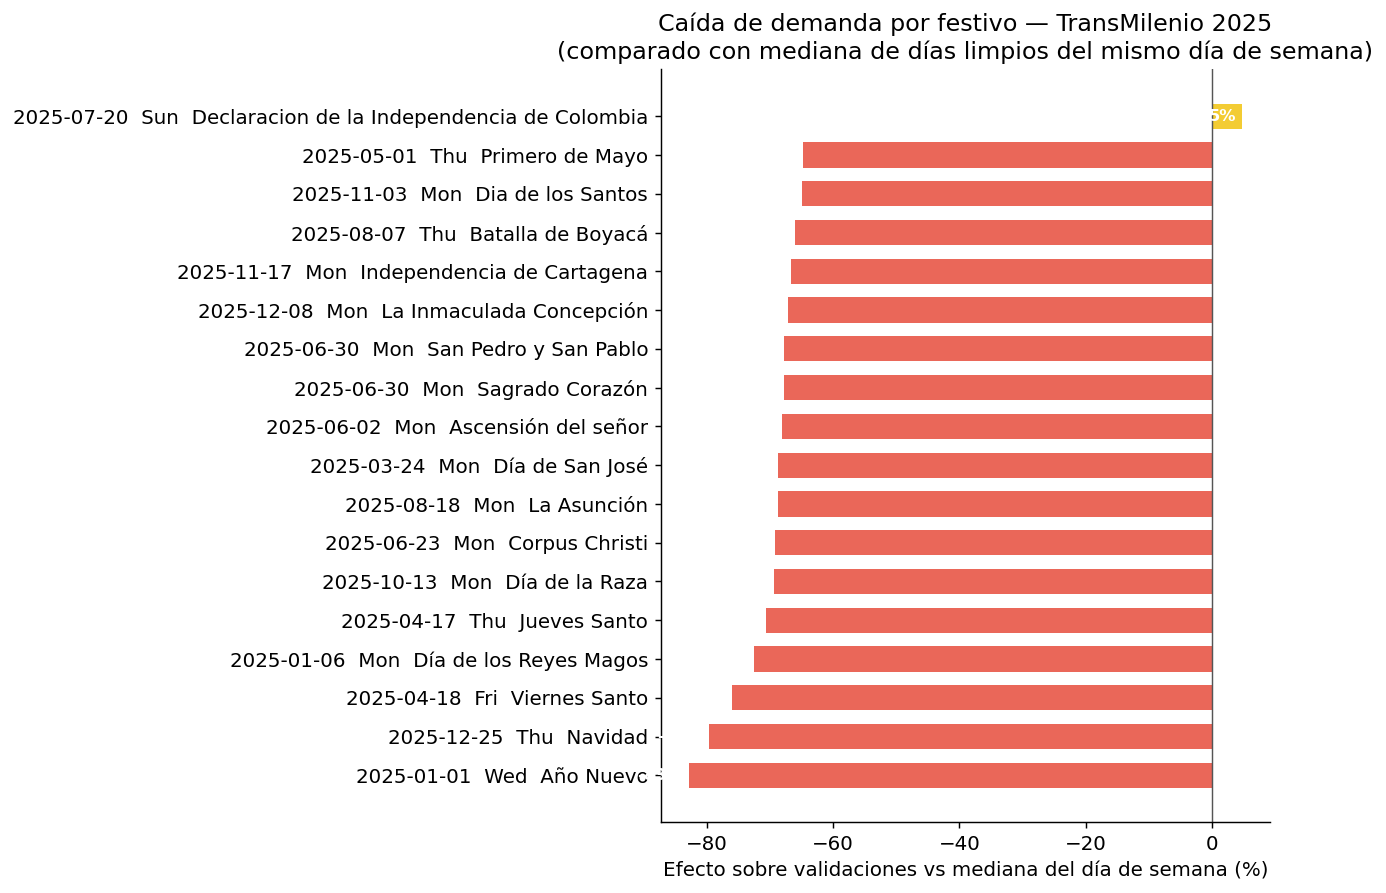

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_bar = ['#e74c3c' if v < -50 else '#e67e22' if v < -30 else '#f1c40f' for v in ind_eff['Efecto (%)']]
bars = ax.barh(
    y=ind_eff.apply(lambda r: f"{r['Fecha']}  {r['Día']}  {r['Festivo']}", axis=1),
    width=ind_eff['Efecto (%)'],
    color=colors_bar, alpha=0.85, height=0.65,
)

for bar, val in zip(bars, ind_eff['Efecto (%)']):
    ax.text(val - 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va='center', ha='right', fontsize=9, color='white', fontweight='bold')

ax.axvline(0, color='#555', lw=0.8)
ax.set_xlabel("Efecto sobre validaciones vs mediana del día de semana (%)")
ax.set_title("Caída de demanda por festivo — TransMilenio 2025\n(comparado con mediana de días limpios del mismo día de semana)")
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/efectos_individuales_festivos.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test de pre-tendencias

Si los festivos son exógenos (como es el caso — están determinados por ley), los coeficientes pre-evento ($k < -1$) deben ser estadísticamente indistinguibles de cero.

In [10]:
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

# Modelo restringido: sin coeficientes pre-evento (k < -1)
pre_cols  = [col_name(k) for k in range(-WINDOW, -1)]   # k = -5, -4, -3, -2
post_cols = [col_name(k) for k in range(0, WINDOW + 1)]
base_controls = 'C(dow) + C(month)'

formula_full = 'log_total ~ ' + ' + '.join(pre_cols + post_cols) + ' + ' + base_controls
formula_restr = 'log_total ~ ' + ' + '.join(post_cols) + ' + ' + base_controls

ols_full  = smf.ols(formula_full,  data=daily).fit()
ols_restr = smf.ols(formula_restr, data=daily).fit()

f_test = ols_full.compare_f_test(ols_restr)
print("Test F de pre-tendencias (H₀: todos los β_k = 0 para k < -1):")
print(f"  F({len(pre_cols)}, {int(ols_full.df_resid)}) = {f_test[0]:.3f},  p-value = {f_test[1]:.4f}")
if f_test[1] > 0.1:
    print("  → No se rechaza H₀ ✓  (consistente con exogeneidad de los festivos)")
else:
    print("  → Se rechaza H₀ — revisar especificación o posibles confundidores")

print("\nCoeficientes pre-evento individuales:")
for k in range(-WINDOW, -1):
    col = col_name(k)
    b   = ols_full.params[col]
    p   = ols_full.pvalues[col]
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f"  k={k:+d}  β={b:+.4f}  p={p:.3f}  {sig}")

Test F de pre-tendencias (H₀: todos los β_k = 0 para k < -1):
  F(4, 336) = 3.562,  p-value = 0.0073
  → Se rechaza H₀ — revisar especificación o posibles confundidores

Coeficientes pre-evento individuales:
  k=-5  β=-0.0582  p=0.072  *
  k=-4  β=-0.0511  p=0.113  
  k=-3  β=-0.0570  p=0.086  *
  k=-2  β=-0.0815  p=0.013  **


## 9. Interpretación

- **k = 0**: efecto promedio en el día del festivo — corresponde a la caída documentada en el dataset (−60% a −80% para los festivos más grandes).
- **k = −5 a k = −2**: coeficientes pre-evento cercanos a cero validan la exogeneidad (test de pre-tendencias).
- **k = +1**: efecto del día siguiente — puede ser positivo (recuperación de viajes postpuestos) o negativo (si el festivo es inicio de puente).
- **Heterogeneidad**: los festivos que caen en lunes (puente Ley Emiliani) tienen dinámicas distintas a los que caen a mitad de semana — se puede explorar en el análisis de efectos individuales.

## 10. Análisis por subgrupo: Ley Emiliani (lunes) vs. mitad de semana

La **Ley Emiliani** colombiana traslada ciertos festivos al lunes siguiente, creando puentes de 3 días (sáb–dom–lun). Los festivos que caen a mitad de semana tienen una dinámica distinta: el día anterior (k=−1) es un día hábil y la recuperación post-festivo puede ser más lenta o más rápida según el contexto.

| Tipo | k = −1 | k = 0 | k = +1 |
|---|---|---|---|
| **Lunes (Ley Emiliani)** | Domingo (ya baja demanda) | Lunes festivo | Martes — primer día hábil tras el puente |
| **Mitad de semana (mar–vie)** | Día hábil normal | Festivo | Puede ser otro festivo (Semana Santa) o día hábil |

**Hipótesis:** los lunes Emiliani tendrán una recuperación más abrupta en k=+1 (retorno al trabajo el martes) y menor efecto de anticipación negativa, mientras los festivos de mitad de semana mostrarán colas post-evento más largas.

In [11]:
# Deduplicar por fecha (jun-30 tiene dos registros en la API) y clasificar por tipo
festivos_unique = festivos_df.drop_duplicates('date').copy()

def tipo_festivo(d):
    dow = d.dayofweek  # 0=lun … 6=dom
    if dow == 0:   return 'lunes_puente'
    elif dow == 6: return 'fin_semana'
    else:          return 'mitad_semana'

festivos_unique['tipo'] = festivos_unique['date'].apply(tipo_festivo)

festivos_lunes = set(festivos_unique[festivos_unique.tipo == 'lunes_puente'].date)
festivos_mid   = set(festivos_unique[festivos_unique.tipo == 'mitad_semana'].date)
festivos_fds   = set(festivos_unique[festivos_unique.tipo == 'fin_semana'].date)

for tipo in ['lunes_puente', 'mitad_semana', 'fin_semana']:
    sub = festivos_unique[festivos_unique.tipo == tipo]
    print(f"  {tipo} ({len(sub)}):")
    for _, r in sub.iterrows():
        h = daily[daily.fecha == r.date]
        efecto = ""
        if len(h):
            baseline = daily[daily.n_overlap == 0].groupby('dow')['total'].median()[r.date.dayofweek]
            efecto = f"  {(h.total.values[0] / baseline - 1)*100:+.0f}%"
        print(f"    {r.date.date()}  {r.date.day_name()[:3]}  {r.localName}{efecto}")
    print()

  lunes_puente (10):
    2025-01-06  Mon  Día de los Reyes Magos  -73%
    2025-03-24  Mon  Día de San José  -69%
    2025-06-02  Mon  Ascensión del señor  -68%
    2025-06-23  Mon  Corpus Christi  -69%
    2025-06-30  Mon  San Pedro y San Pablo  -68%
    2025-08-18  Mon  La Asunción  -69%
    2025-10-13  Mon  Día de la Raza  -69%
    2025-11-03  Mon  Dia de los Santos  -65%
    2025-11-17  Mon  Independencia de Cartagena  -67%
    2025-12-08  Mon  La Inmaculada Concepción  -67%

  mitad_semana (6):
    2025-01-01  Wed  Año Nuevo  -83%
    2025-04-17  Thu  Jueves Santo  -71%
    2025-04-18  Fri  Viernes Santo  -76%
    2025-05-01  Thu  Primero de Mayo  -65%
    2025-08-07  Thu  Batalla de Boyacá  -66%
    2025-12-25  Thu  Navidad  -80%

  fin_semana (1):
    2025-07-20  Sun  Declaracion de la Independencia de Colombia  +5%



In [12]:
# Dummies tipo-específicas para cada k en la ventana
for k in range(-WINDOW, WINDOW + 1):
    daily[f'lun_{col_name(k)}'] = daily.fecha.apply(
        lambda d, k=k: int((d - pd.Timedelta(days=k)) in festivos_lunes)
    )
    daily[f'mid_{col_name(k)}'] = daily.fecha.apply(
        lambda d, k=k: int((d - pd.Timedelta(days=k)) in festivos_mid)
    )

n_lun = daily['lun_es_p0'].sum()
n_mid = daily['mid_es_p0'].sum()
print(f"Días k=0 lunes_puente : {n_lun}")
print(f"Días k=0 mitad_semana : {n_mid}")
print(f"Festivos fin de semana : {len(festivos_fds)} (excluidos del modelo — n insuficiente)")

Días k=0 lunes_puente : 10
Días k=0 mitad_semana : 6
Festivos fin de semana : 1 (excluidos del modelo — n insuficiente)


In [13]:
# Modelo conjunto: dummies de ambos tipos en una sola regresión
# Omitir k=-1 de ambos grupos como baseline
lun_cols = [f'lun_{col_name(k)}' for k in range(-WINDOW, WINDOW + 1) if k != -1]
mid_cols = [f'mid_{col_name(k)}' for k in range(-WINDOW, WINDOW + 1) if k != -1]

formula_sub = 'log_total ~ ' + ' + '.join(lun_cols + mid_cols) + ' + C(dow) + C(month)'
ols_sub = smf.ols(formula_sub, data=daily).fit(cov_type='HC3')

print(f"N = {int(ols_sub.nobs)} días  |  R²= {ols_sub.rsquared:.3f}  R²_adj = {ols_sub.rsquared_adj:.3f}")
print()

# Extraer coeficientes por tipo
def extract_coefs(prefix):
    rows = []
    for k in range(-WINDOW, WINDOW + 1):
        if k == -1:
            rows.append({'k': k, 'b': 0., 'lo': 0., 'hi': 0., 'pval': np.nan})
            continue
        col = f'{prefix}{col_name(k)}'
        ci  = ols_sub.conf_int().loc[col]
        rows.append({'k': k, 'b': ols_sub.params[col],
                     'lo': ci[0], 'hi': ci[1], 'pval': ols_sub.pvalues[col]})
    return pd.DataFrame(rows).set_index('k')

res_lun = extract_coefs('lun_')
res_mid = extract_coefs('mid_')

# Tabla comparativa
header = f"{'k':>3}  {'β_lunes':>8}  {'% lunes':>8}  {'sig':>3}  │  {'β_midweek':>9}  {'% midweek':>9}  {'sig':>3}"
print(header)
print("─" * len(header))
for k in range(-WINDOW, WINDOW + 1):
    rl, rm = res_lun.loc[k], res_mid.loc[k]
    if k == -1:
        print(f"{k:>3}  {'baseline':>8}  {'—':>8}  {'':>3}  │  {'baseline':>9}  {'—':>9}  {'':>3}")
        continue
    pct_l = (np.exp(rl.b) - 1) * 100
    pct_m = (np.exp(rm.b) - 1) * 100
    sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f"{k:>+3}  {rl.b:>+8.4f}  {pct_l:>+7.1f}%  {sig(rl.pval):>3}  │  "
          f"{rm.b:>+9.4f}  {pct_m:>+8.1f}%  {sig(rm.pval):>3}")

N = 364 días  |  R²= 0.959  R²_adj = 0.954

  k   β_lunes   % lunes  sig  │  β_midweek  % midweek  sig
──────────────────────────────────────────────────────────
 -5   -0.0707     -6.8%       │    -0.0215      -2.1%     
 -4   -0.1018     -9.7%   **  │    +0.0240      +2.4%     
 -3   -0.0639     -6.2%   **  │    -0.0725      -7.0%     
 -2   -0.0822     -7.9%   **  │    -0.0895      -8.6%     
 -1  baseline         —       │   baseline          —     
 +0   -1.1426    -68.1%  ***  │    -1.2945     -72.6%  ***
 +1   -0.0155     -1.5%       │    -0.2514     -22.2%  ***
 +2   +0.0164     +1.7%       │    -0.2071     -18.7%  ***
 +3   -0.0199     -2.0%       │    -0.0611      -5.9%     
 +4   -0.0356     -3.5%   **  │    -0.0566      -5.5%     
 +5   -0.0116     -1.2%       │    -0.0439      -4.3%     


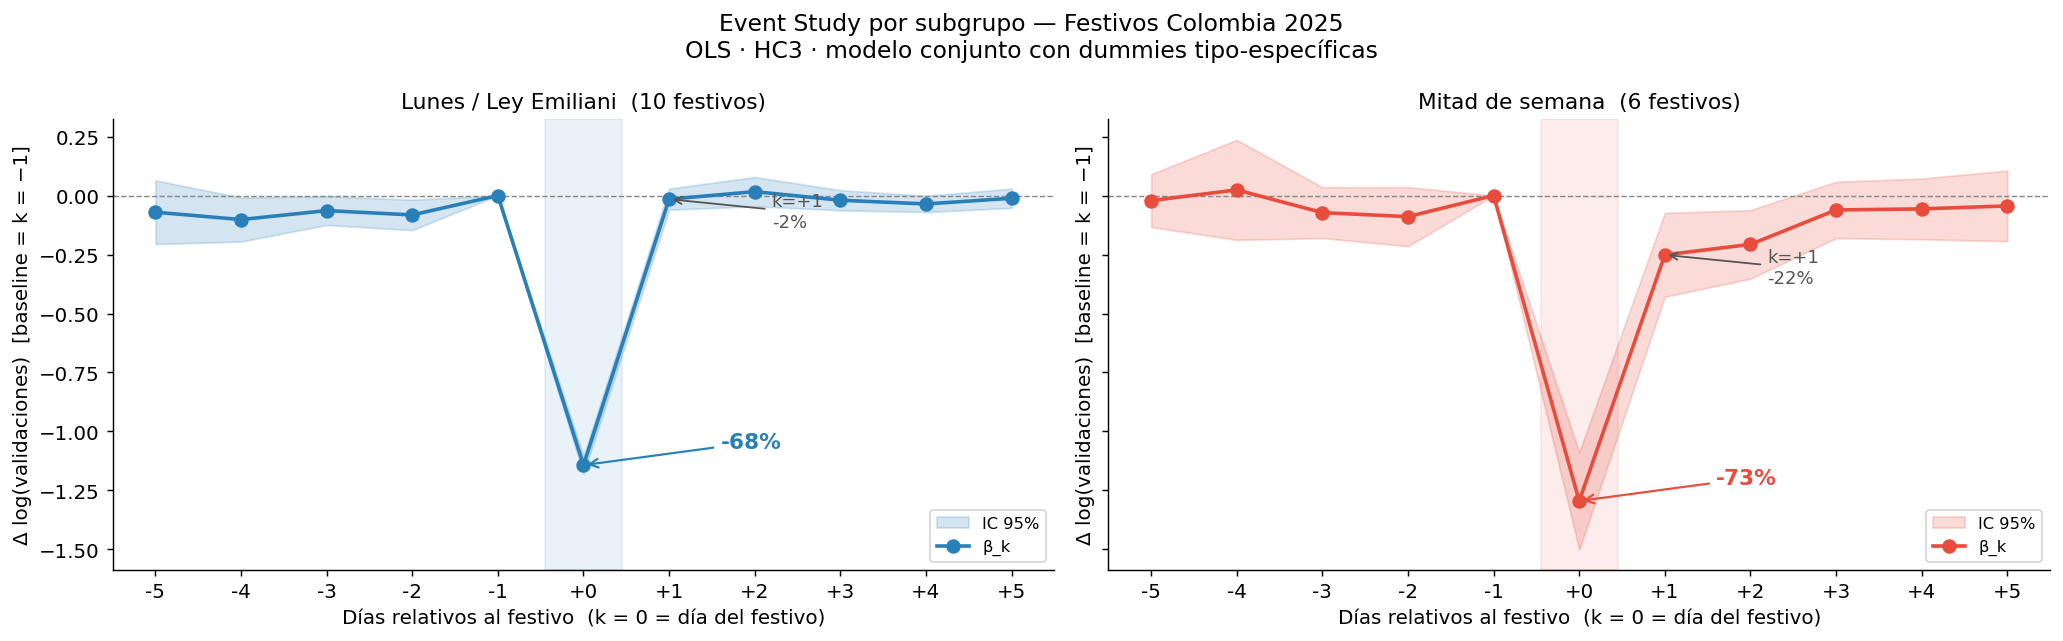

Figura guardada en reports/figures/event_study_festivos_subgrupos.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

specs = [
    (axes[0], res_lun, '#2980b9', f'Lunes / Ley Emiliani  ({len(festivos_lunes)} festivos)'),
    (axes[1], res_mid, '#e74c3c', f'Mitad de semana  ({len(festivos_mid)} festivos)'),
]

for ax, res_df, color, title in specs:
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.axvspan(-0.45, 0.45, alpha=0.10, color=color, zorder=0)
    ax.fill_between(res_df.index, res_df.lo, res_df.hi, alpha=0.20, color=color, label='IC 95%')
    ax.plot(res_df.index, res_df.b, 'o-', color=color, ms=7, lw=2, label='β_k')

    b0  = res_df.loc[0, 'b']
    pct = (np.exp(b0) - 1) * 100
    ax.annotate(f"{pct:+.0f}%", xy=(0, b0), xytext=(1.6, b0 + 0.07),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                color=color, fontweight='bold', fontsize=12)

    # Marcar k=+1 con anotación explícita
    b1  = res_df.loc[1, 'b']
    pct1 = (np.exp(b1) - 1) * 100
    ax.annotate(f"k=+1\n{pct1:+.0f}%", xy=(1, b1), xytext=(2.2, b1 - 0.12),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.0),
                color='#555', fontsize=10)

    ax.set_xticks(range(-WINDOW, WINDOW + 1))
    ax.set_xticklabels([f'{k:+d}' for k in range(-WINDOW, WINDOW + 1)])
    ax.set_xlabel("Días relativos al festivo  (k = 0 = día del festivo)")
    ax.set_ylabel("Δ log(validaciones)  [baseline = k = −1]")
    ax.set_title(title, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)

fig.suptitle(
    "Event Study por subgrupo — Festivos Colombia 2025\n"
    "OLS · HC3 · modelo conjunto con dummies tipo-específicas",
    fontsize=13
)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/event_study_festivos_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en reports/figures/event_study_festivos_subgrupos.png")

In [15]:
# Test formal de igualdad entre grupos para k=0, k=+1 y k=+2
# H₀: β_k(lunes) = β_k(midweek)
print("Test de igualdad entre grupos (restricción lineal sobre el modelo conjunto):\n")

for k_test, label in [(0, 'día del festivo'), (1, 'día siguiente (k=+1)'), (2, 'dos días después (k=+2)')]:
    col_l = f'lun_{col_name(k_test)}'
    col_m = f'mid_{col_name(k_test)}'
    f_res = ols_sub.f_test(f'({col_l} = {col_m})')
    b_l   = ols_sub.params[col_l]
    b_m   = ols_sub.params[col_m]
    dif   = (np.exp(b_l) - 1)*100 - (np.exp(b_m) - 1)*100
    fval  = float(np.atleast_1d(f_res.fvalue).flat[0])
    sig   = '***' if f_res.pvalue < 0.01 else ('**' if f_res.pvalue < 0.05 else ('*' if f_res.pvalue < 0.1 else '(ns)'))
    print(f"  k={k_test:+d}  [{label}]")
    print(f"    Lunes    : β={b_l:+.4f}  →  {(np.exp(b_l)-1)*100:+.1f}%")
    print(f"    Midweek  : β={b_m:+.4f}  →  {(np.exp(b_m)-1)*100:+.1f}%")
    print(f"    Diferencia: {dif:+.1f} pp  |  F={fval:.3f}  p={f_res.pvalue:.4f}  {sig}")
    print()

Test de igualdad entre grupos (restricción lineal sobre el modelo conjunto):

  k=+0  [día del festivo]
    Lunes    : β=-1.1426  →  -68.1%
    Midweek  : β=-1.2945  →  -72.6%
    Diferencia: +4.5 pp  |  F=2.000  p=0.1582  (ns)

  k=+1  [día siguiente (k=+1)]
    Lunes    : β=-0.0155  →  -1.5%
    Midweek  : β=-0.2514  →  -22.2%
    Diferencia: +20.7 pp  |  F=6.366  p=0.0121  **

  k=+2  [dos días después (k=+2)]
    Lunes    : β=+0.0164  →  +1.7%
    Midweek  : β=-0.2071  →  -18.7%
    Diferencia: +20.4 pp  |  F=7.922  p=0.0052  ***



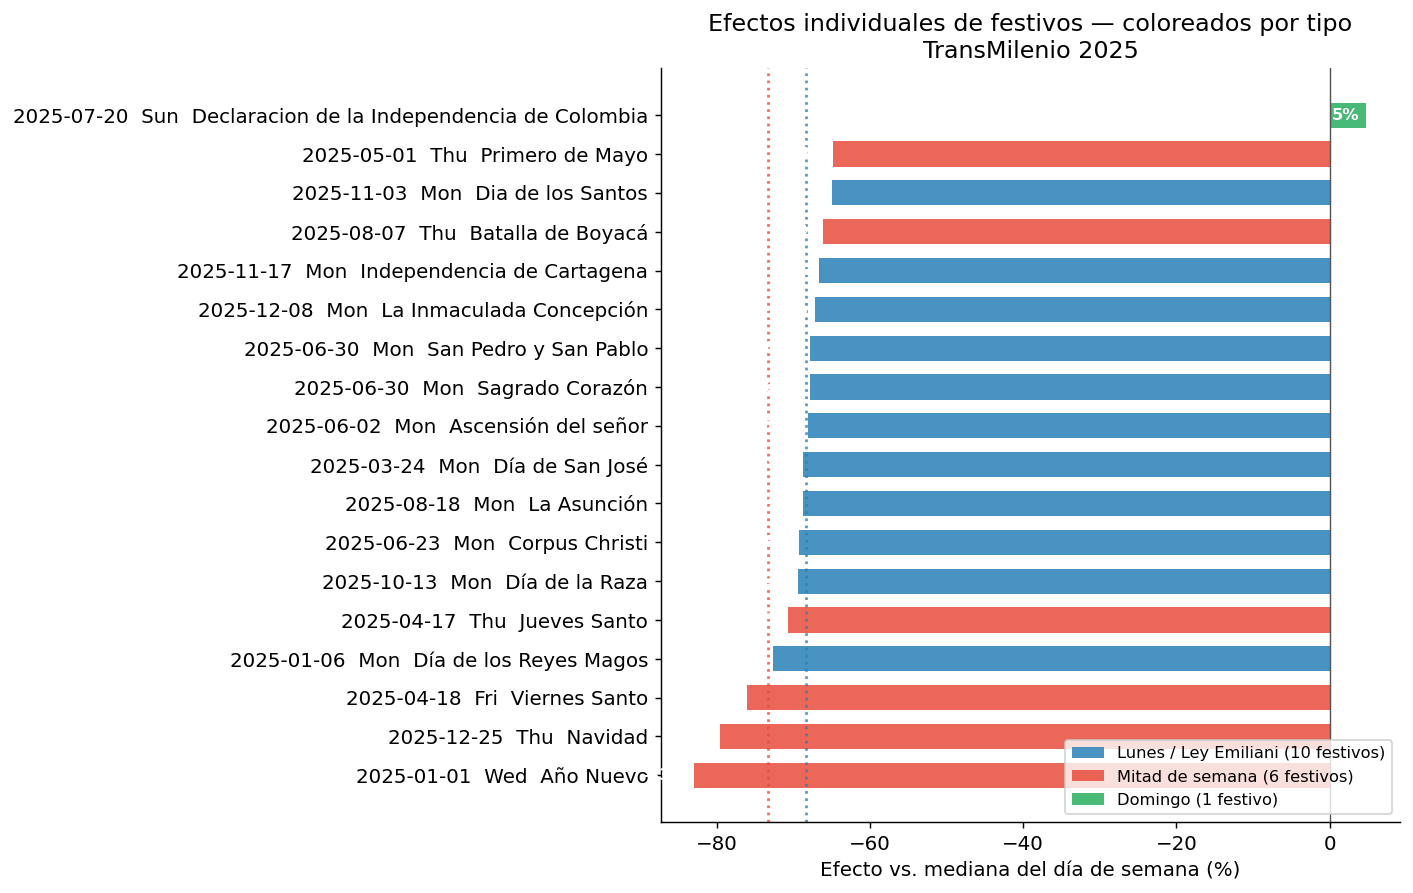

Figura guardada en reports/figures/efectos_individuales_festivos_tipo.png


In [16]:
# Efectos individuales coloreados por tipo de festivo
from matplotlib.patches import Patch

tipo_map = festivos_unique.set_index('date')['tipo'].to_dict()
ind_eff['tipo'] = ind_eff['Fecha'].apply(
    lambda d: tipo_map.get(pd.Timestamp(d), 'fin_semana')
)

COLOR = {'lunes_puente': '#2980b9', 'mitad_semana': '#e74c3c', 'fin_semana': '#27ae60'}
bar_colors = [COLOR[t] for t in ind_eff['tipo']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    y=ind_eff.apply(lambda r: f"{r['Fecha']}  {r['Día']}  {r['Festivo']}", axis=1),
    width=ind_eff['Efecto (%)'],
    color=bar_colors, alpha=0.85, height=0.65,
)
for bar, val in zip(bars, ind_eff['Efecto (%)']):
    ax.text(val - 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va='center', ha='right', fontsize=9, color='white', fontweight='bold')

# Medias por tipo (excluir fin_semana)
for tipo, color in [('lunes_puente', '#2980b9'), ('mitad_semana', '#e74c3c')]:
    media = ind_eff[ind_eff.tipo == tipo]['Efecto (%)'].mean()
    ax.axvline(media, color=color, lw=1.5, ls=':', alpha=0.8, label=f'Media {tipo}: {media:.0f}%')

ax.axvline(0, color='#555', lw=0.8)
legend_elements = [
    Patch(facecolor='#2980b9', alpha=0.85, label=f'Lunes / Ley Emiliani ({len(festivos_lunes)} festivos)'),
    Patch(facecolor='#e74c3c', alpha=0.85, label=f'Mitad de semana ({len(festivos_mid)} festivos)'),
    Patch(facecolor='#27ae60', alpha=0.85, label='Domingo (1 festivo)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlabel("Efecto vs. mediana del día de semana (%)")
ax.set_title("Efectos individuales de festivos — coloreados por tipo\nTransMilenio 2025")
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/efectos_individuales_festivos_tipo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en reports/figures/efectos_individuales_festivos_tipo.png")